<a href="https://colab.research.google.com/github/NinaHRO/CIS-3902-AI-and-ML/blob/main/DataMining_Project_Template_Spring_2026_(1)_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Project Template (GitHub + Colab)
## Nina Ross
## 4/12/2026
## Employee Burnout

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand



In [ ]:
%matplotlib inline

# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Imbalanced-learn for oversampling
!pip install imblearn -q
from imblearn.over_sampling import SMOTE


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 55.8 MB/s eta 0:00:00
Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Deliverable 1: Problem Framing & Data Acquisition

## What to include in this markdown cell

- What problem are you trying to solve?
- What is the **target variable**?
- What organization, industry, or domain could use this model?
- Why does this problem matter?
- Where did the dataset come from?
- Why did you choose this dataset?



## Data loading options

Choose **one** of the options below:
- load a CSV from GitHub
- upload a CSV into Colab
- read from a direct URL

Keep your original raw data file in your GitHub repository whenever possible.


In [ ]:
import pandas as pd

data_path = "https://raw.githubusercontent.com/NinaHRO/CIS3902-1-Project/main/tech_mental_health_burnout.csv"
df = pd.read_csv(data_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   job_role                 150000 non-null  object 
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  object 
 5   work_mode                150000 non-null  object 
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  phys

In [ ]:
df.head()

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,5.9,5.1,6.1,5.9,2,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,6.3,5.2,1.1,7.1,1,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,8.4,5.9,6.2,5.1,0,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,7.0,3.2,5.3,6.9,6,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,5.6,2.4,3.9,7.3,2,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [ ]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (150000, 25)


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,5.9,5.1,6.1,5.9,2,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,6.3,5.2,1.1,7.1,1,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,8.4,5.9,6.2,5.1,0,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,7.0,3.2,5.3,6.9,6,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,5.6,2.4,3.9,7.3,2,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  object 
 2   job_role                 150000 non-null  object 
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  object 
 5   work_mode                150000 non-null  object 
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  phys

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,150000.0,NaN,NaN,NaN,38.02534,9.510609,22.0,30.0,38.0,46.0,54.0
gender,150000,3,Male,82286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_role,150000,8,Software Engineer,37623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_years,150000.0,NaN,NaN,NaN,5.05501,2.878602,0.0,3.0,5.0,7.0,18.5
company_size,150000,4,Large,37623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_mode,150000,3,Hybrid,60056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_hours_per_week,150000.0,NaN,NaN,NaN,47.00758,7.89331,30.0,42.0,47.0,52.0,84.0
overtime_hours,150000.0,NaN,NaN,NaN,6.12718,3.783618,0.0,3.0,6.0,9.0,24.0
meetings_per_day,150000.0,NaN,NaN,NaN,4.010893,1.978316,0.0,3.0,4.0,5.0,12.0
deadlines_missed,150000.0,NaN,NaN,NaN,1.284193,1.426264,0.0,0.0,1.0,2.0,5.0


In [ ]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary)


,0


In [ ]:
# TODO: Replace with your actual target column name
target = "burnout_level"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
burnout_level,
Low,131620
Moderate,18315
High,65


,proportion
burnout_level,
Low,0.877467
Moderate,0.122100
High,0.000433


In [ ]:
# Identify feature columns
X = df.drop(columns=[target, 'burnout_score']) # Dropping burnout_score as per student summary
y = df[target]

# If needed, convert target labels here
# Example:
# y = y.map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'job_role', 'company_size', 'work_mode']
Numeric columns: ['age', 'experience_years', 'work_hours_per_week', 'overtime_hours', 'meetings_per_day', 'deadlines_missed', 'job_satisfaction', 'manager_support', 'work_life_balance', 'sleep_hours', 'physical_activity_days', 'screen_time_hours', 'caffeine_intake', 'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score', 'depression_score', 'seeks_professional_help']


## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


In [ ]:
# Install and run AutoViz in Colab if needed
# You may comment this out if AutoViz is already installed in your runtime

#!pip install autoviz

from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


Shape of your Data Set loaded: (150000, 25)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  14
    Number of Integer-Categorical Columns =  4
    Number of String-Categorical Columns =  4
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  2
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    24 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
Since Number of Rows in data 150000 exceeds maximum, randomly sampling 150000 rows for EDA

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
age,int64,0.000000,0,22.000000,54.000000,No issue
gender,object,0.000000,0,,,No issue
job_role,object,0.000000,0,,,No issue
experience_years,float64,0.000000,NA,0.000000,18.500000,Column has 537 outliers greater than upper bound (13.00) or lower than lower bound(-3.00). Cap them or remove them.
company_size,object,0.000000,0,,,No issue
work_mode,object,0.000000,0,,,No issue
work_hours_per_week,float64,0.000000,NA,30.000000,84.000000,Column has 752 outliers greater than upper bound (67.00) or lower than lower bound(27.00). Cap them or remove them.
overtime_hours,float64,0.000000,NA,0.000000,24.000000,Column has 112 outliers greater than upper bound (18.00) or lower than lower bound(-6.00). Cap them or remove them.
meetings_per_day,float64,0.000000,NA,0.000000,12.000000,Column has 1811 outliers greater than upper bound (8.00) or lower than lower bound(0.00). Cap them or remove them.
deadlines_missed,int64,0.000000,0,0.000000,5.000000,No issue


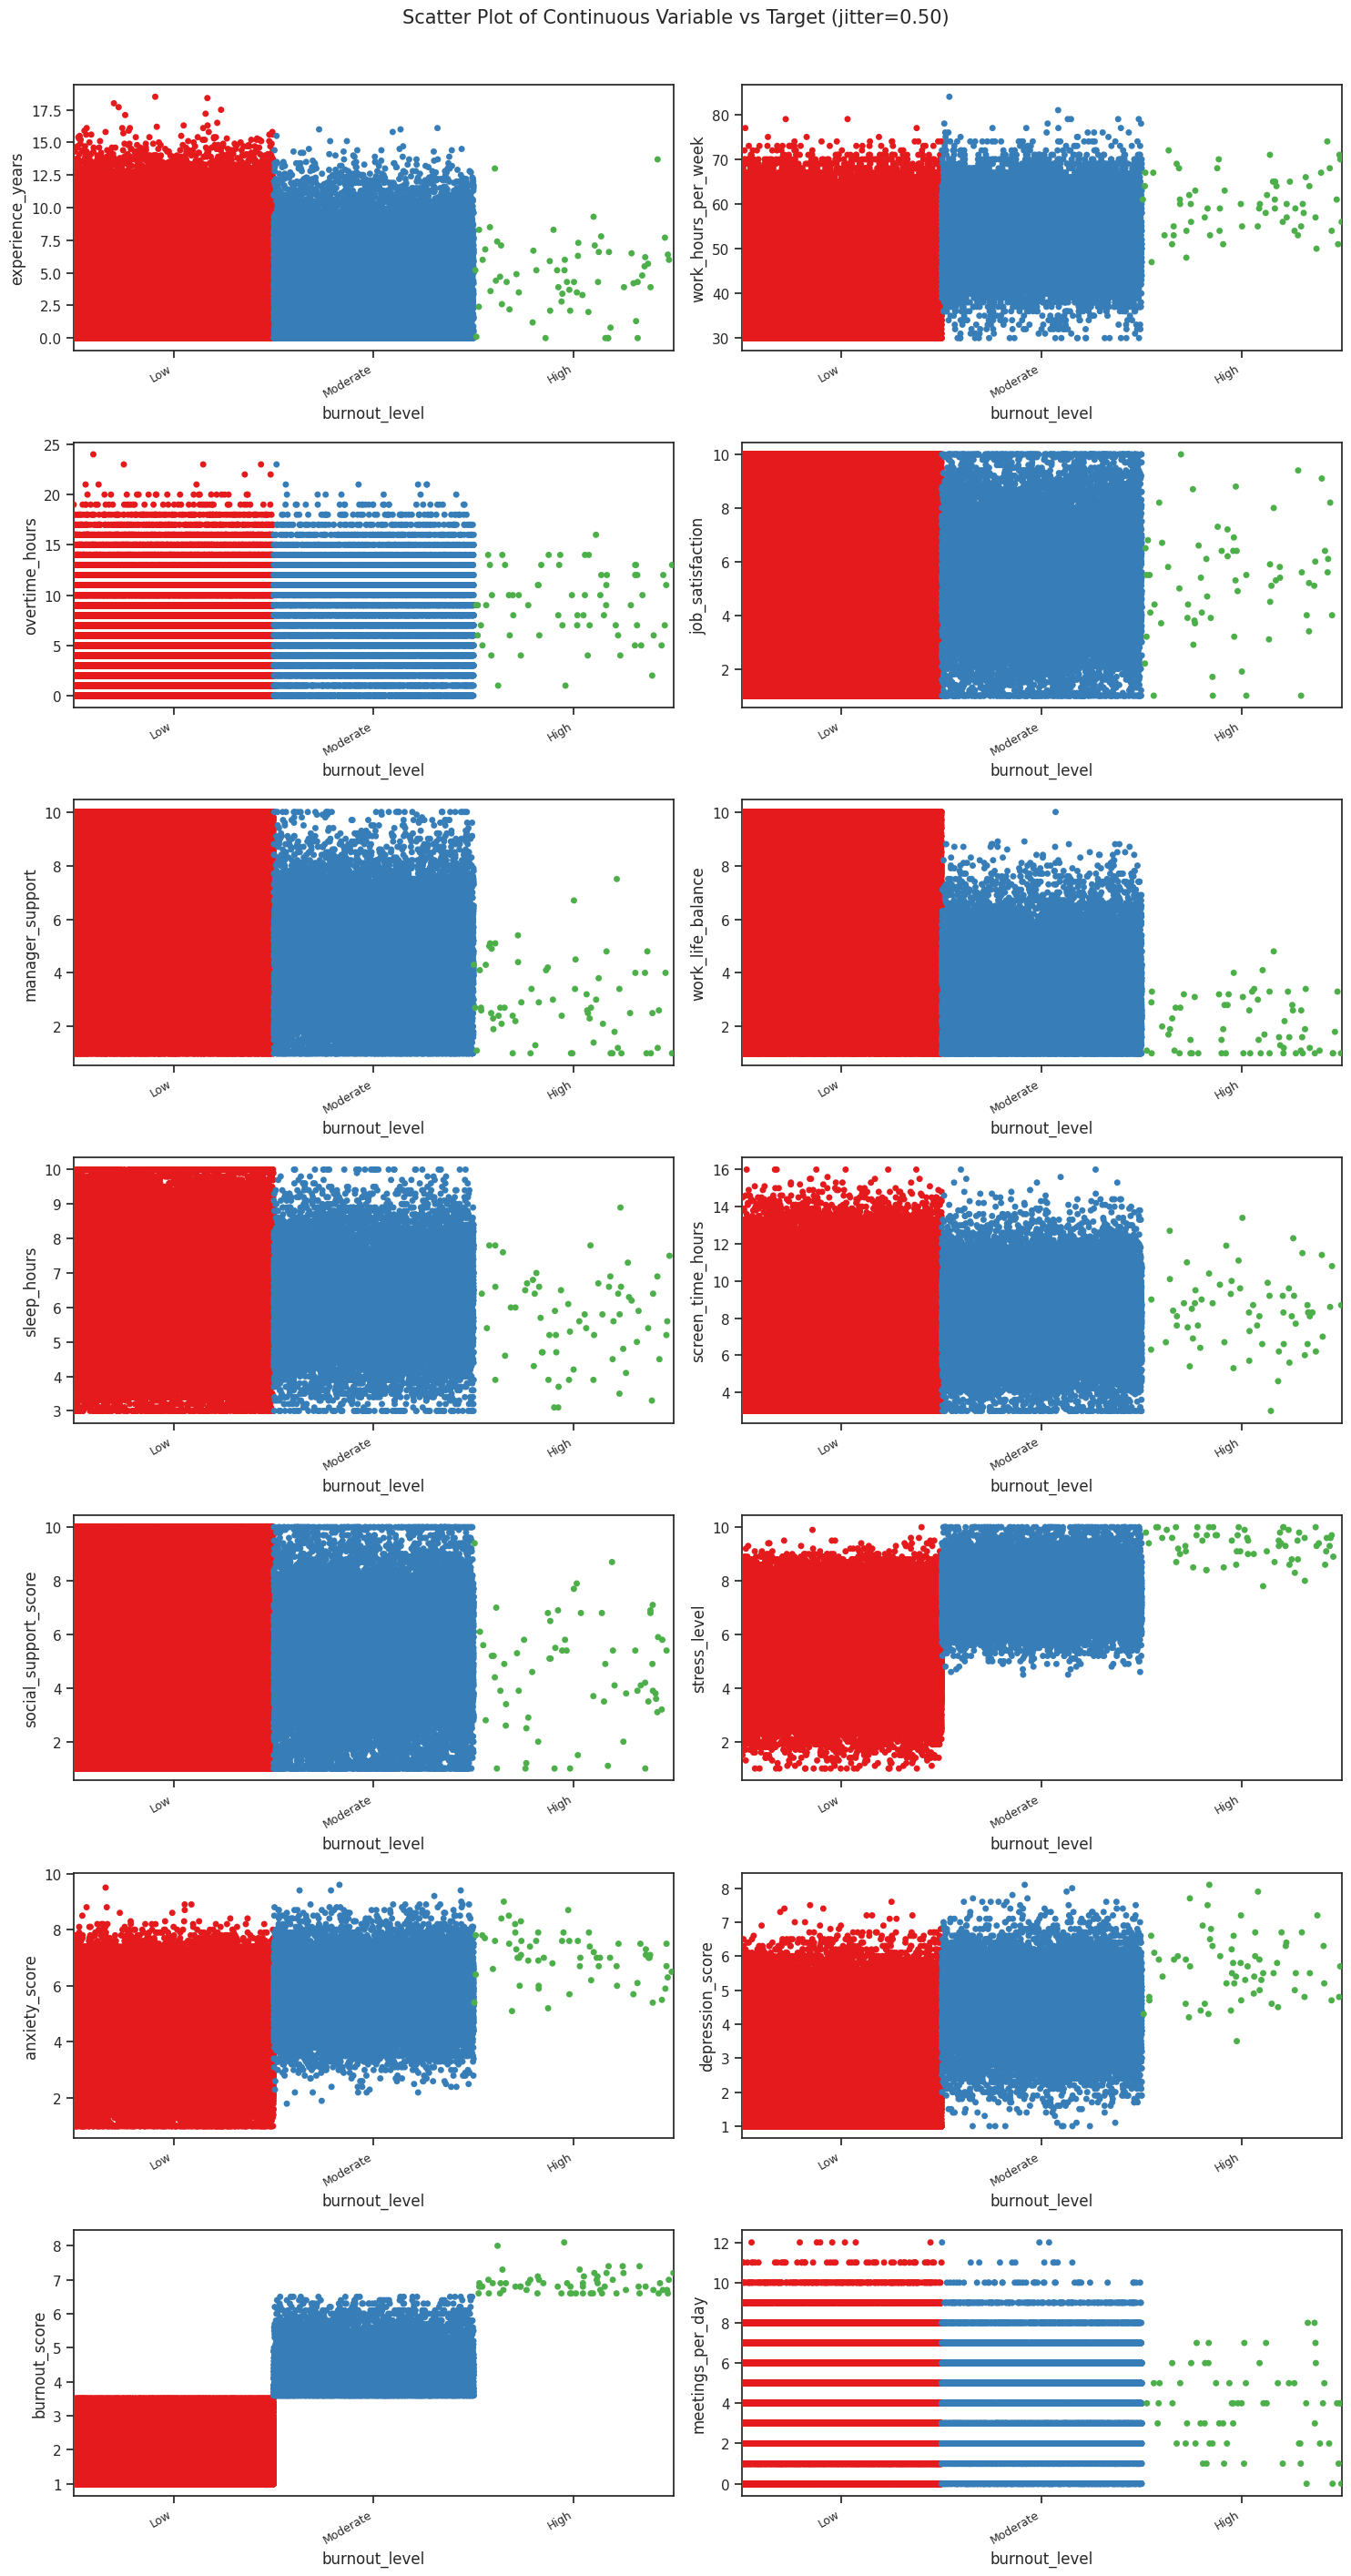

Total Number of Scatter Plots = 105


KeyboardInterrupt: 

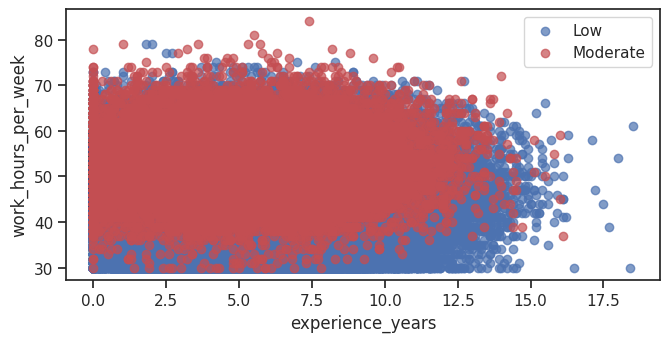

In [ ]:
# AutoViz example
# Replace target with your real target column name before running
dfte = AV.AutoViz(
     "",
     sep=",",
     depVar=target,
     dfte=df,
     header=0,
     verbose=1,
     lowess=False,
     chart_format="svg",
     max_rows_analyzed=150000,
     max_cols_analyzed=30
 )

# Clear any queued figures after AutoViz so later plots behave normally in Colab
import matplotlib.pyplot as plt
plt.close('all')

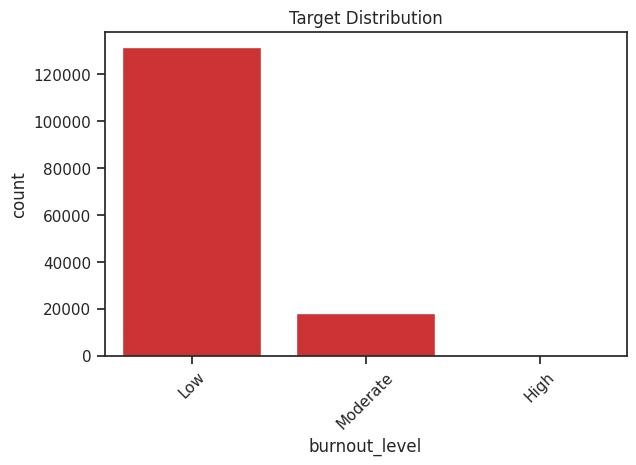

In [ ]:
# Code for custom visualiations (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Example 1: target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target)
plt.title("Target Distribution")
plt.xticks(rotation=45)
plt.show()

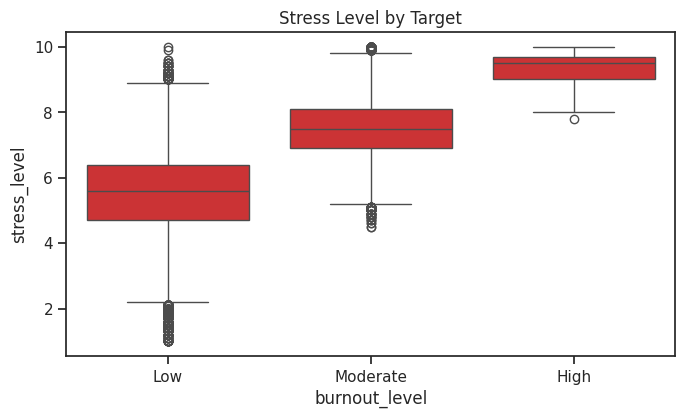

In [ ]:
# Example 3: relationship to target
# Replace with columns from your dataset
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x=target, y='stress_level')
plt.title("Stress Level by Target")
plt.show()

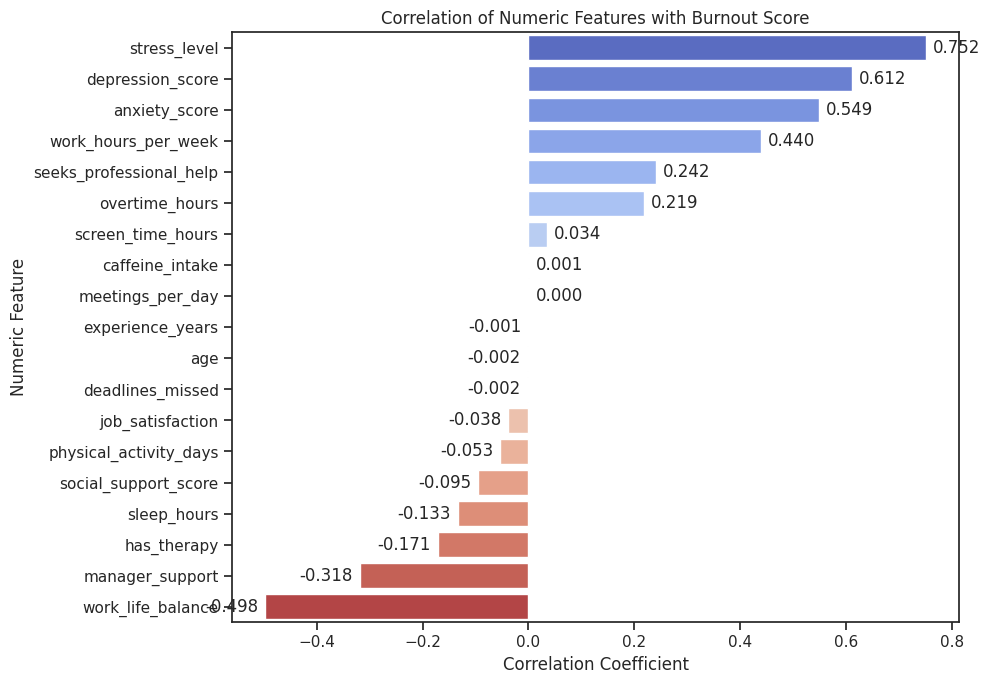

In [ ]:
plt.figure(figsize=(10, 7))

# Calculate correlations with 'burnout_score'
# Exclude 'burnout_score' itself from the list of features to correlate against it
correlations = df[numeric_cols].corrwith(df['burnout_score']).sort_values(ascending=False)

# Create the bar plot
ax = sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

# Add exact correlation values on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

plt.title('Correlation of Numeric Features with Burnout Score')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Numeric Feature')
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

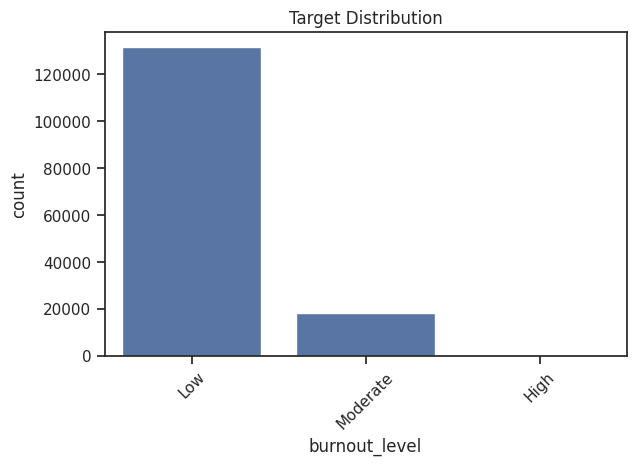

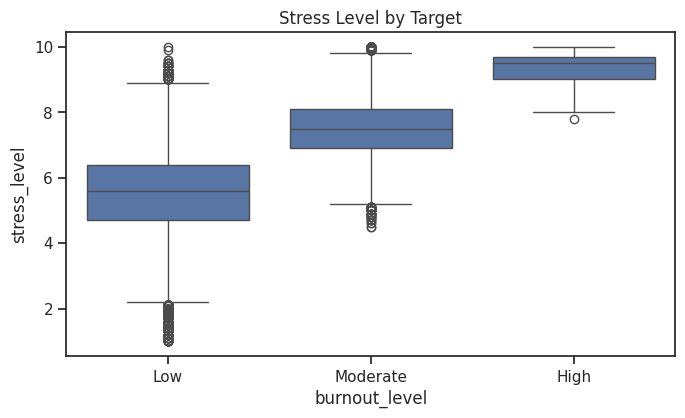

<Figure size 1000x700 with 0 Axes>

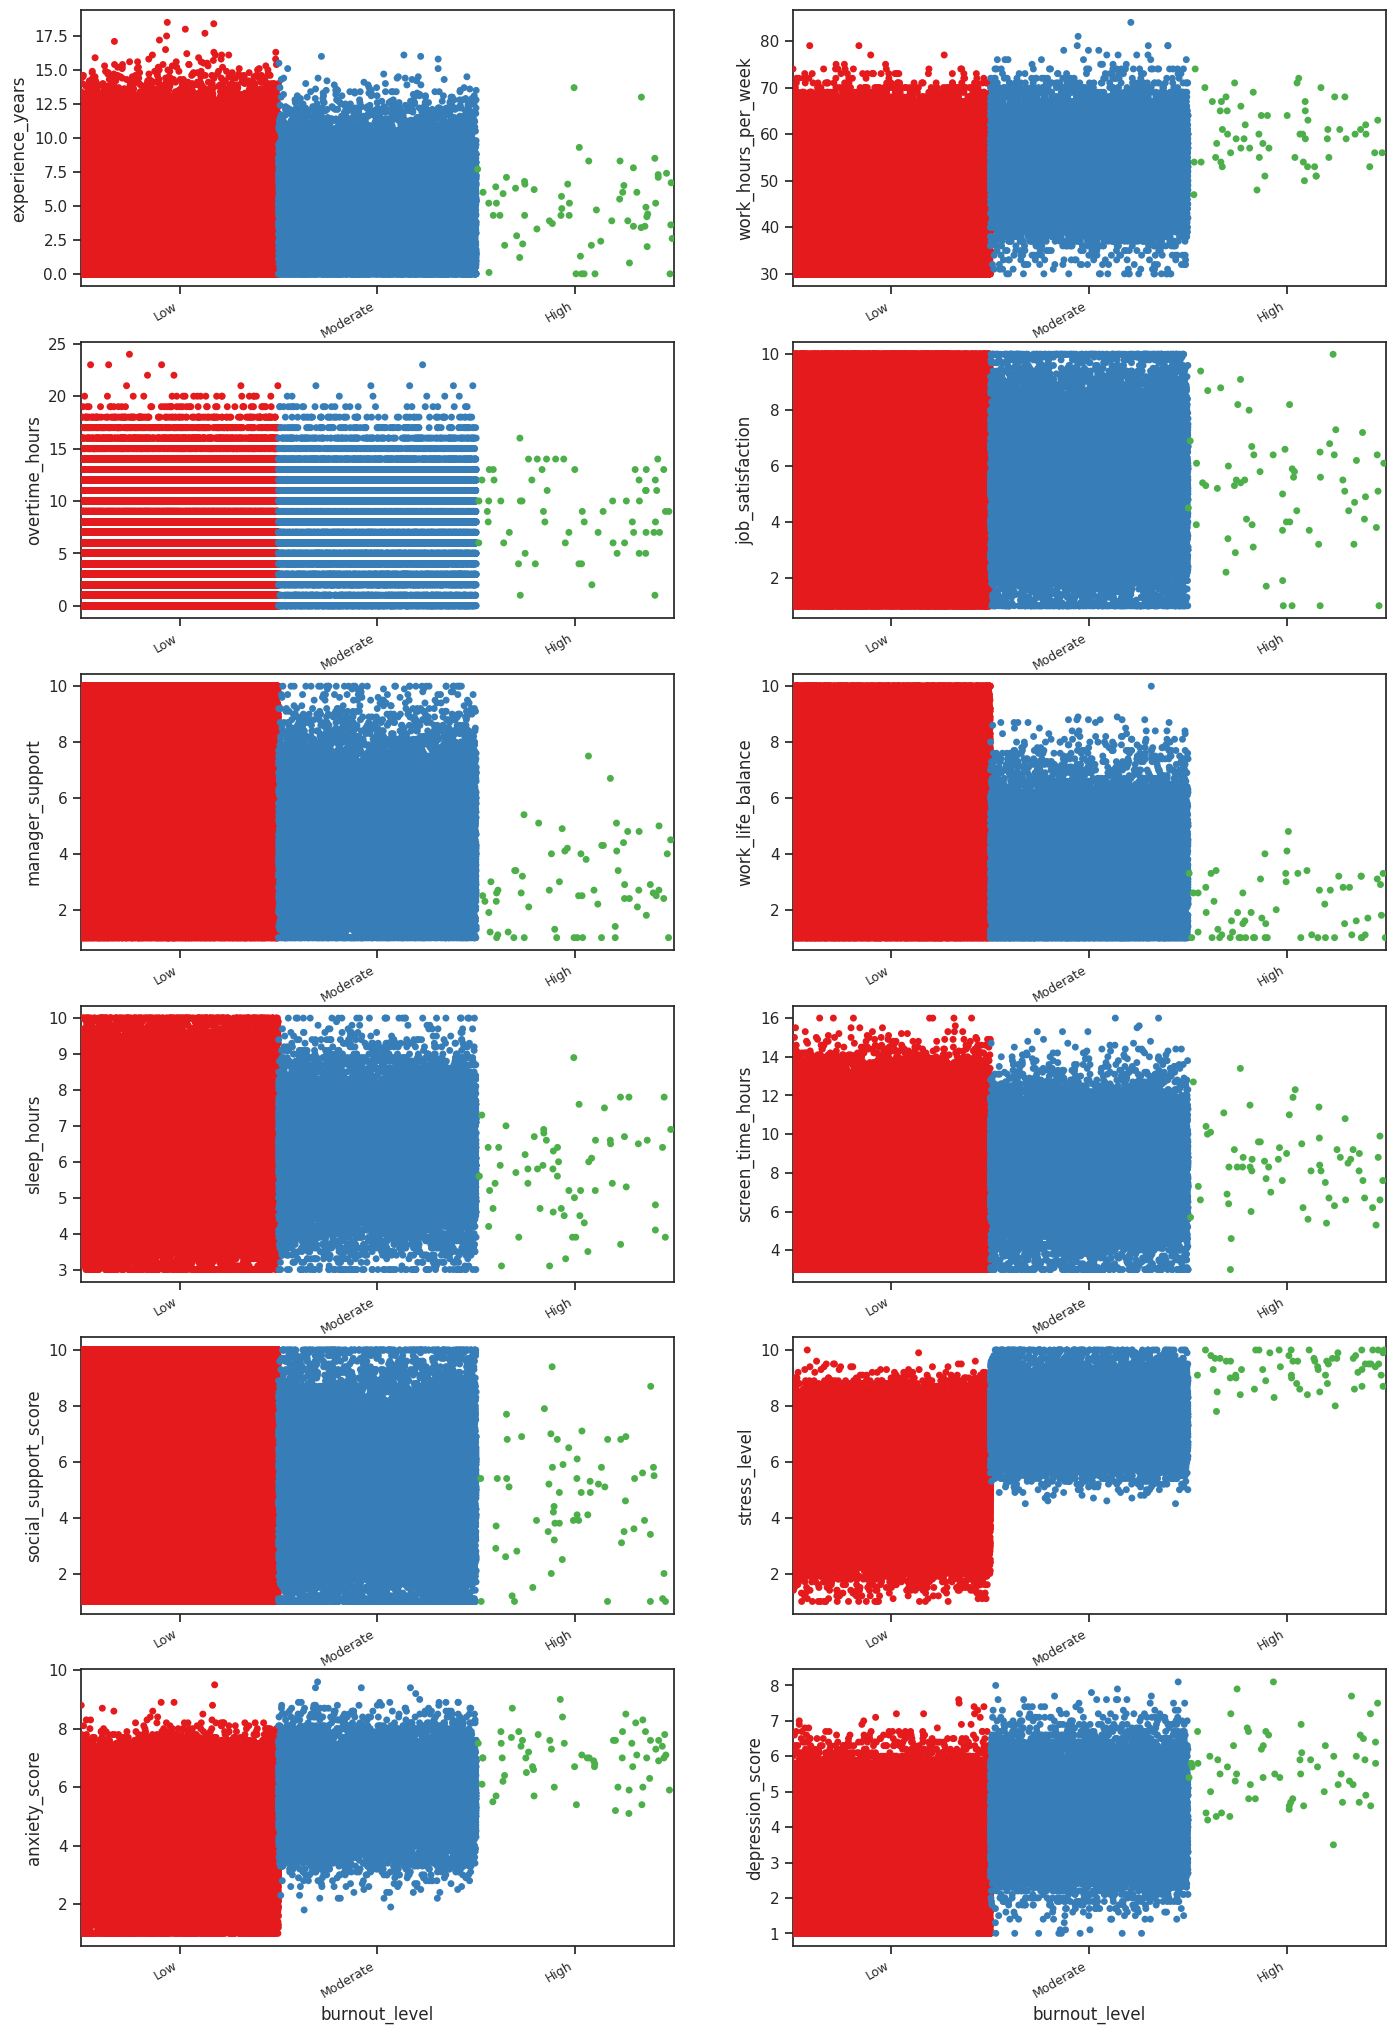

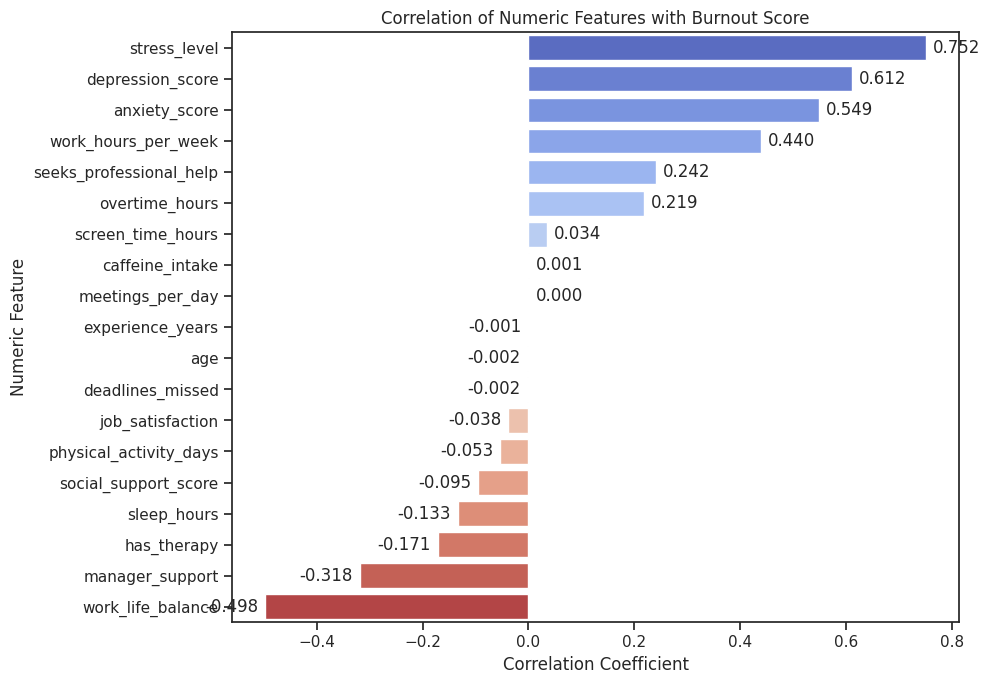

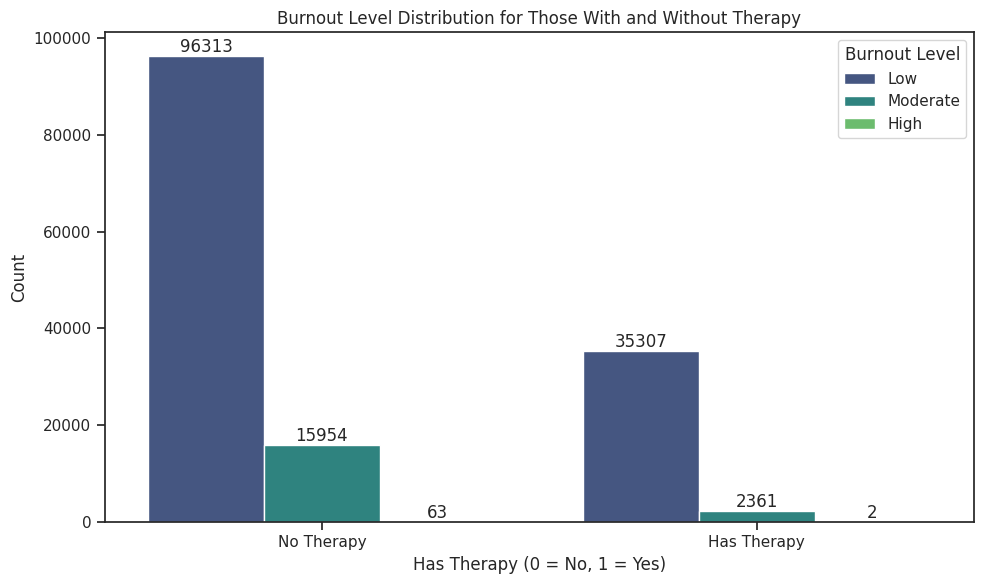

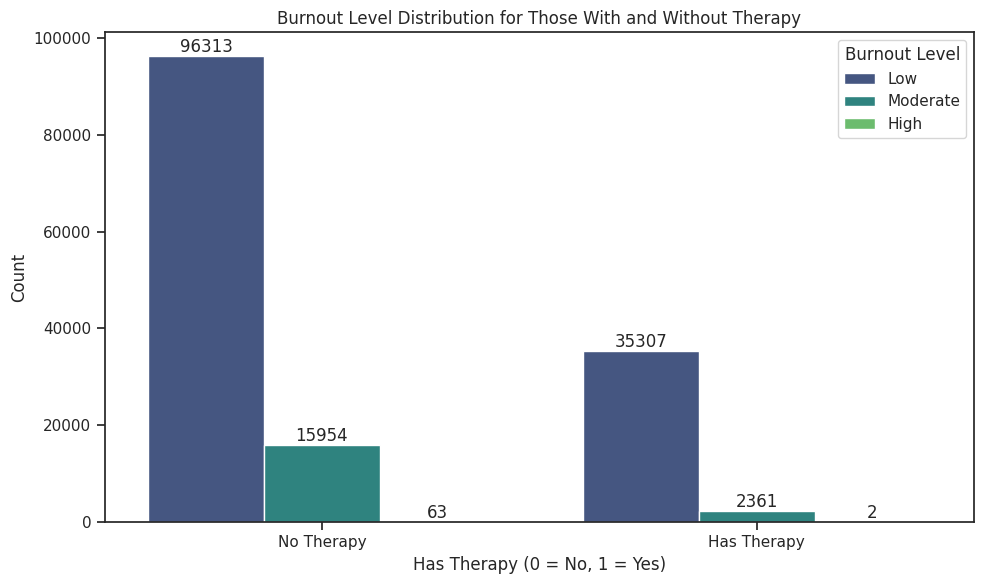

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='has_therapy', hue=target, palette='viridis')
plt.title('Burnout Level Distribution for Those With and Without Therapy')
plt.xlabel('Has Therapy (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Therapy', 'Has Therapy'])
plt.legend(title='Burnout Level')

# Add exact counts on top of the bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [ ]:
%matplotlib inline

## Data preparation plan

Explain your preparation steps in plain language:
- columns dropped
- missing value handling
- encoding categorical variables
- train/test split strategy
- any feature engineering

Write a short summary in the markdown cell below this one.





### Student preparation summary
I did not have to handle any missing values due to the dataset I have chosen. In the future I may drop any columns that do not have correlation towards burnout_level. For categorical variables I simply used binary for yes/no answers. I will use 70% of the data for training and 30% for testing. In the future I will balance burnout_level categories (low,mid,high) due to the vast majority being in low and mid burnout. Also, I will remove burnout_score due to it being the same as burnout_level.



# Deliverable 3: Model Development, Evaluation & Interpretation

## What to include
- preprocessing pipeline
- Random Forest model
- parameter tuning
- evaluation on the test set
- confusion matrix
- kappa
- feature importance
- interpretation of what the results mean

## Reminder
You should explain results in a business-friendly way, not only with technical language.


In [ ]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)

In [ ]:
import pandas as pd

data_path = "https://raw.githubusercontent.com/NinaHRO/CIS3902-1-Project/main/tech_mental_health_burnout.csv"
df = pd.read_csv(data_path)

# TODO: Replace with your actual target column name
target = "burnout_level"

# Identify feature columns
X = df.drop(columns=[target, 'burnout_score']) # Dropping burnout_score as per student summary
y = df[target]

# If needed, convert target labels here
# Example:
# y = y.map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'job_role', 'company_size', 'work_mode']
Numeric columns: ['age', 'experience_years', 'work_hours_per_week', 'overtime_hours', 'meetings_per_day', 'deadlines_missed', 'job_satisfaction', 'manager_support', 'work_life_balance', 'sleep_hours', 'physical_activity_days', 'screen_time_hours', 'caffeine_intake', 'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score', 'depression_score', 'seeks_professional_help']


In [ ]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) # Added StandardScaler for numeric features
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

In [ ]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        13
         Low       0.94      0.98      0.96     26324
    Moderate       0.79      0.53      0.63      3663

    accuracy                           0.93     30000
   macro avg       0.57      0.50      0.53     30000
weighted avg       0.92      0.93      0.92     30000

Cohen's Kappa: 0.5959


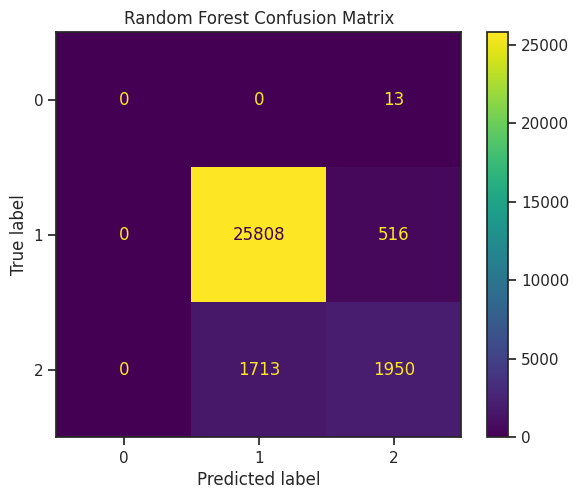

In [ ]:
# Confusion matrix
import matplotlib.pyplot as plt

plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()


## Hyperparameter tuning

We do not know the best settings ahead of time, so we try multiple combinations.

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [ ]:
# Preprocess once
from sklearn.model_selection import RandomizedSearchCV

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Model
rf = RandomForestClassifier(random_state=123)

# Smaller, faster search space
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_leaf": [1, 2]
}

grid_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=5,
    cv=2,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=123
)

grid_search.fit(X_train_processed, y_train)
best_rf = grid_search.best_estimator_


In [ ]:
# Final evaluation on the test set
# Preprocess X_test using the same preprocessor fitted on X_train_processed
X_test_processed = preprocessor.transform(X_test)
best_preds = best_rf.predict(X_test_processed)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        13
         Low       0.93      0.98      0.96     26324
    Moderate       0.80      0.48      0.60      3663

    accuracy                           0.92     30000
   macro avg       0.58      0.49      0.52     30000
weighted avg       0.91      0.92      0.91     30000

Cohen's Kappa: 0.5556


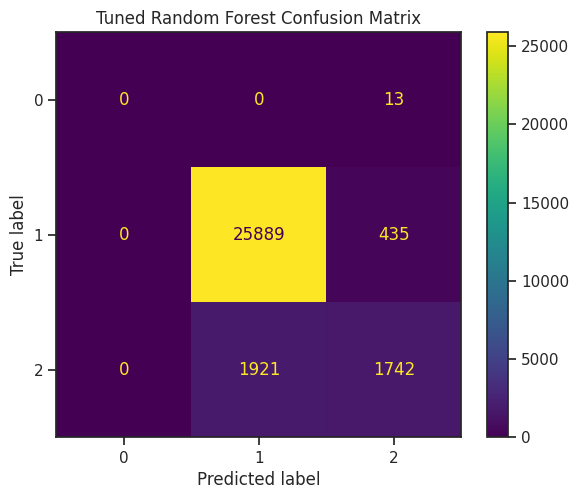

In [ ]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

Be careful:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


In [ ]:
# Feature importance from the tuned model
import pandas as pd

# Get feature names after preprocessing. The 'preprocessor' object was fitted in cell 1b201a22.
feature_names = preprocessor.get_feature_names_out()

# Get feature importances directly from the best_rf model, which is a RandomForestClassifier
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))

,feature,importance
15,num__stress_level,0.361051
17,num__depression_score,0.142232
2,num__work_hours_per_week,0.116437
16,num__anxiety_score,0.104636
8,num__work_life_balance,0.092209
7,num__manager_support,0.044045
18,num__seeks_professional_help,0.024266
3,num__overtime_hours,0.019176
14,num__has_therapy,0.018719
13,num__social_support_score,0.010529


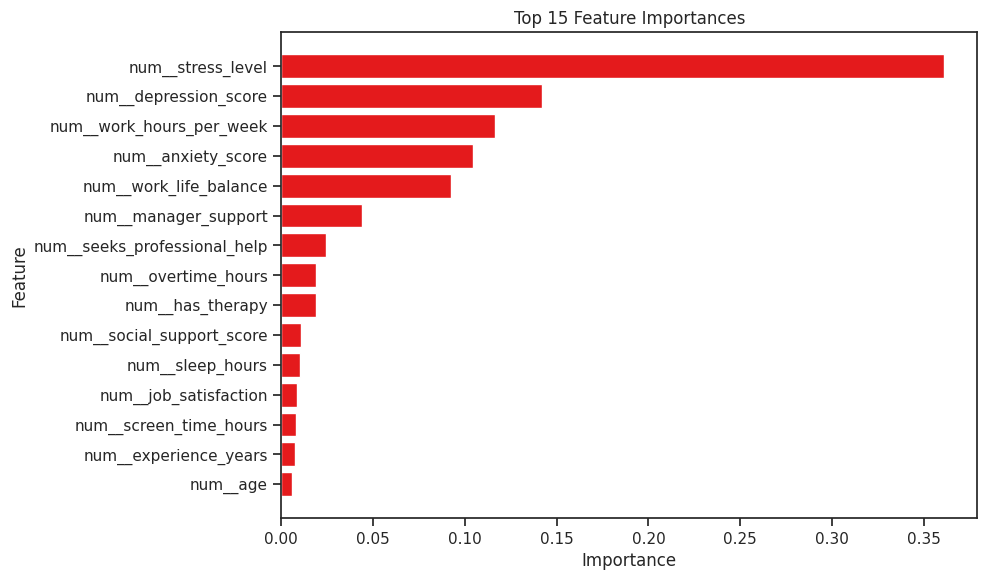

In [ ]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Re-training Model After Dropping Low-Influence Columns

Based on the low feature importances observed for the one-hot encoded components of 'gender', 'job_role', 'company_size', and 'work_mode', these original categorical columns will be dropped to simplify the model and potentially improve performance by removing noisy features.

In [ ]:
# Identify columns to drop based on very low feature importance (e.g., < 0.001)
# Inspecting the feature_importance_df, the one-hot encoded components of
# 'gender', 'job_role', 'company_size', and 'work_mode' all have extremely low importance.
# Thus, we drop the original categorical columns.
columns_to_drop_from_X = [
    'gender', 'job_role', 'company_size', 'work_mode',
    'job_satisfaction', 'screen_time_hours', 'experience_years', 'age',
    'deadlines_missed', 'physical_activity_days', 'sleep_hours', 'meetings_per_day', 'caffeine_intake'
]

# Redefine X without these columns
X_new = df.drop(columns=[target, 'burnout_score'] + columns_to_drop_from_X)
y_new = df[target]

# Identify new categorical and numeric columns
categorical_cols_new = X_new.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols_new = X_new.select_dtypes(include=["number"]).columns.tolist()

print("New Categorical columns:", categorical_cols_new)
print("New Numeric columns:", numeric_cols_new)


New Categorical columns: []
New Numeric columns: ['work_hours_per_week', 'overtime_hours', 'manager_support', 'work_life_balance', 'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score', 'depression_score', 'seeks_professional_help']


In [ ]:
# Rebuild preprocessing pipeline based on whether categorical columns exist

# Ensure numeric_transformer and categorical_transformer are defined
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


if not categorical_cols_new:
    preprocessor_new = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols_new)
        ]
    )
else:
    preprocessor_new = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols_new),
            ("cat", categorical_transformer, categorical_cols_new)
        ]
    )

In [ ]:
# Train/test split with new X and y
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.20, random_state=123, stratify=y_new
)

In [ ]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV # Import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline # Import Pipeline from imblearn

# Re-run the tuning pipeline with the updated preprocessor and data
rf_tuning_pipeline_new = ImbPipeline(steps=[
    ("preprocessor", preprocessor_new),
    ("smote", SMOTE(random_state=123)), # Add SMOTE for oversampling
    ("model", RandomForestClassifier(random_state=123))
])

# Corrected search space for pipeline parameters
param_grid = {
    "smote__k_neighbors": [3, 5], # Tune k_neighbors for SMOTE
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10],
    "model__min_samples_leaf": [1, 2]
}

# Change GridSearchCV to RandomizedSearchCV
grid_search_new = RandomizedSearchCV(
    estimator=rf_tuning_pipeline_new,
    param_distributions=param_grid, # Use param_distributions for RandomizedSearchCV
    n_iter=10, # Number of parameter settings that are sampled
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=123 # For reproducibility
)

grid_search_new.fit(X_train_new, y_train_new)
best_rf_new = grid_search_new.best_estimator_

print("Best Parameters (New Model):", grid_search_new.best_params_)

Best Parameters (New Model): {'smote__k_neighbors': 3, 'model__n_estimators': 50, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


In [ ]:
# Final evaluation on the test set
RandomForestClassifier(class_weight="balanced")

best_preds_new = best_rf_new.predict(X_test_new)

print("Tuned Random Forest Classification Report (New Model):")
print(classification_report(y_test_new, best_preds_new))

kappa_new = cohen_kappa_score(y_test_new, best_preds_new)
print("Cohen's Kappa (New Model):", round(kappa_new, 4))

Tuned Random Forest Classification Report (New Model):
              precision    recall  f1-score   support

        High       0.14      0.46      0.21        13
         Low       0.98      0.88      0.93     26324
    Moderate       0.50      0.87      0.64      3663

    accuracy                           0.88     30000
   macro avg       0.54      0.74      0.59     30000
weighted avg       0.92      0.88      0.89     30000

Cohen's Kappa (New Model): 0.5734


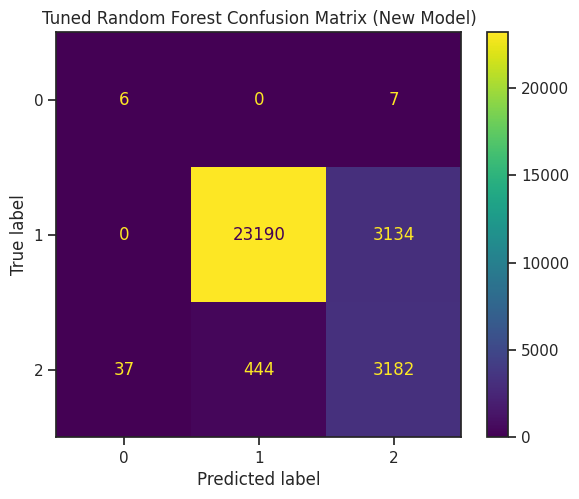

In [ ]:
# Tuned confusion matrix
import matplotlib.pyplot as plt
plt.close('all')
cm_new = confusion_matrix(y_test_new, best_preds_new)

fig, ax = plt.subplots(figsize=(6, 5))
disp_new = ConfusionMatrixDisplay(confusion_matrix=cm_new)
disp_new.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix (New Model)")
plt.show()

In [ ]:
# Feature importance from the tuned model
import pandas as pd

feature_names_new = best_rf_new.named_steps["preprocessor"].get_feature_names_out()
importances_new = best_rf_new.named_steps["model"].feature_importances_

feature_importance_df_new = pd.DataFrame({
    "feature": feature_names_new,
    "importance": importances_new
}).sort_values("importance", ascending=False)

display(feature_importance_df_new.head(15))

,feature,importance
11,num__stress_level,0.325609
13,num__depression_score,0.154916
0,num__work_hours_per_week,0.118908
5,num__work_life_balance,0.118680
12,num__anxiety_score,0.115035
4,num__manager_support,0.059324
1,num__overtime_hours,0.024030
14,num__seeks_professional_help,0.022415
10,num__has_therapy,0.016892
9,num__social_support_score,0.012438


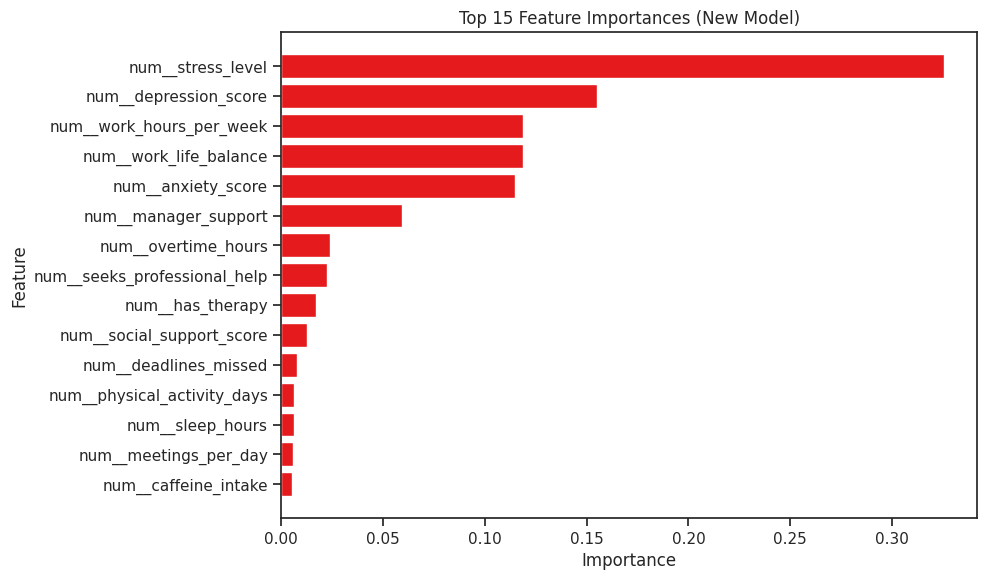

In [ ]:
# Plot top feature importances
top_n_new = 15
top_features_new = feature_importance_df_new.head(top_n_new).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features_new["feature"], top_features_new["importance"])
plt.title(f"Top {top_n_new} Feature Importances (New Model)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Interpretation prompts

Write short answers below:
- How well did the model perform?
- Which class was easier or harder to predict?
- Which variables seemed most important?
- Where did the model make mistakes?
- How could this model be used by a real organization?
- What would you improve next?


### Student interpretation summary
The model performed as expected, the large sample size of low and medium burnout had a good recall rate. The sample size of below 100 for high burnout had a 0% on recall before SMOTE.

It was easy to predict low and medium burnout. Due to the extremely SMALL sample size of high burnout it was nearly impossible to guess it.

Stress, depression, and anxiety are big factors of burnout. When it comes to mental health, these factors are a big influence to decreasing energy.

The model itself did not make any mistakes. It was the sample size that was the problem, once SMOTE was inserted it had a better result on high burnout recall due to more synthetic minority sampling.

This model can be used as a reflection of what worked and what did not. It leads to the question of why are there such a huge minority of high burnout when it is studied and observed everywhere. Studying what makes a good survey creates better data for better models.

I would focus on finding data that represents the burnout population more. But, I like the idea of using data that has problems such as low samples because it represents real life. If we are studying burnout, we can understand that those who are inflicted may not take surveys which is represented by the low sample size. We see our biggest indicators in predicting high burnout, so for the next survey it would be wise to focus on those topics to get a better result.

# Optional: Save your final processed data file and model

You may save your trained model if you want to show a deployment-style step.


In [ ]:
import joblib

# Example:
# joblib.dump(best_rf, "final_model.pkl")
# print("Model saved.")

# saving data file
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
df_clean.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)

MessageError: Error: credential propagation was unsuccessful